In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
users_info = pd.read_csv('users_info.csv')
users_info.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
3,1003,Москва,NaN,NaN
4,1004,Екатеринбург,60.0,male


### EDA

In [3]:
users_info.shape

(1000, 4)

In [4]:
users_info.dtypes

id_user      int64
city        object
age        float64
gender      object
dtype: object

In [5]:
users_info.isnull().sum()

id_user     0
city        0
age        88
gender     89
dtype: int64

In [6]:
users_info = users_info[~users_info['age'].isnull()]
users_info = users_info[~users_info['gender'].isnull()]

In [7]:
users_info.isnull().sum()

id_user    0
city       0
age        0
gender     0
dtype: int64

In [8]:
users_info['age'].describe()

count    865.000000
mean      39.419653
std       13.774501
min       18.000000
25%       28.000000
50%       37.000000
75%       51.000000
max       65.000000
Name: age, dtype: float64

In [9]:
Q1 = np.percentile(users_info['age'], 25)
Q3 = np.percentile(users_info['age'], 75)
IQR = Q3 - Q1
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR
print(lower_bound)
print(upper_bound)

-6.5
85.5


In [10]:
users_info_clean = users_info.loc[users_info['age']< upper_bound].copy()
users_info_clean.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
4,1004,Екатеринбург,60.0,male
5,1005,СПб,35.0,female


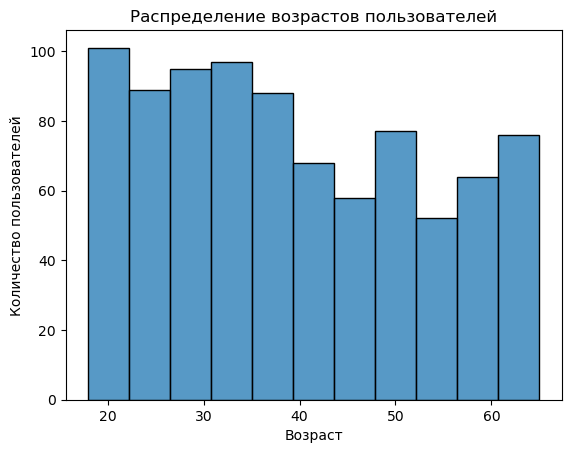

In [11]:
sns.histplot(users_info_clean['age'])
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.title('Распределение возрастов пользователей')
plt.show()

### Доля пользователей-женщин по городам

In [12]:
users_info_clean.groupby(['city','gender']).agg(cnt_user = ('id_user', 'count')).reset_index()

,city,gender,cnt_user
0,Екатеринбург,female,55
1,Екатеринбург,male,78
2,Казань,female,53
3,Казань,male,77
4,Москва,female,220
5,Москва,male,105
6,СПб,female,123
7,СПб,male,154


In [13]:
users_info_pivot = users_info.pivot_table(
                                index='city',
                                columns='gender',
                                values='id_user',
                                aggfunc='count',
                                fill_value=0
                               )
users_info_pivot.head()

gender,female,male
city,,
Екатеринбург,55,78
Казань,53,77
Москва,220,105
СПб,123,154


In [14]:
users_info_pivot.columns = ['female', 'male']
users_info_pivot['women_share'] = users_info_pivot['female'] / (users_info_pivot['female'] + users_info_pivot['male'])
users_info_pivot.head()

,female,male,women_share
city,,,
Екатеринбург,55,78,0.413534
Казань,53,77,0.407692
Москва,220,105,0.676923
СПб,123,154,0.444043


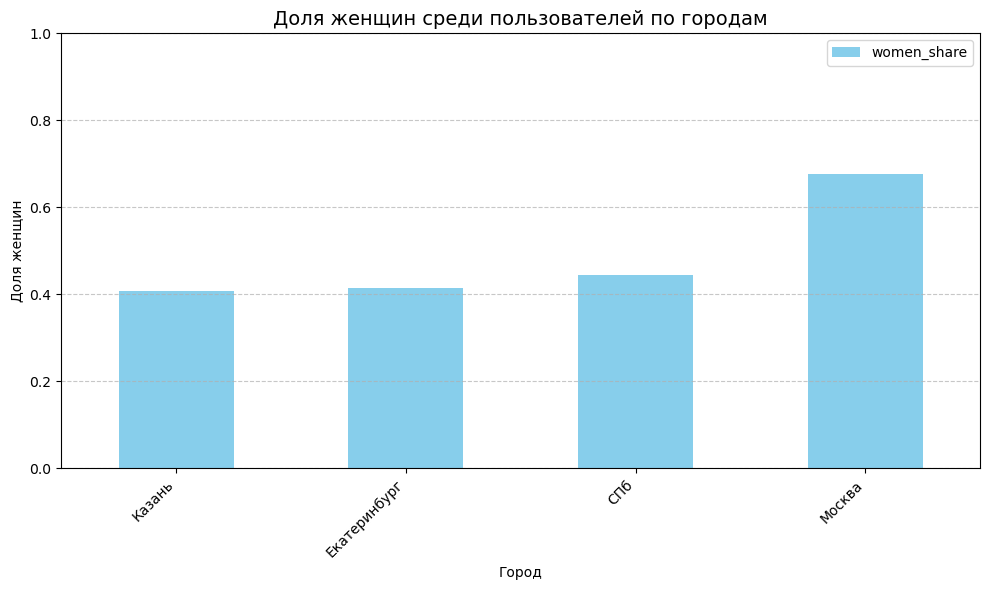

In [15]:
plt.figure(figsize=(10, 6))
users_info_pivot['women_share'].sort_values().plot(kind='bar', color='skyblue')
plt.title('Доля женщин среди пользователей по городам', fontsize=14)
plt.ylabel('Доля женщин')
plt.xlabel('Город')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Делим пользователей на бины

In [16]:
pay_mon = pd.read_csv('payments_monthly.csv')
pay_mon.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0,3600,2,3600
1,1000,2023-04,0,4,0,7200,4,7200
2,1000,2023-05,0,4,0,6400,4,6400
3,1000,2023-06,0,2,0,3600,2,3600
4,1000,2023-07,0,4,0,7200,4,7200


In [17]:
arg_cnt_total = pay_mon.groupby('id_user')['cnt_total'].mean().reset_index()
arg_cnt_total.columns = ['id_user', 'avg']
bins = [1, 4, 9, float('inf')]
labels = ['мало', 'средне', 'много']
arg_cnt_total['group'] = pd.cut(arg_cnt_total['avg'], bins=bins, labels=labels, right=True)
counts_gr = arg_cnt_total['group'].value_counts()

In [18]:
pay_mon.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0,3600,2,3600
1,1000,2023-04,0,4,0,7200,4,7200
2,1000,2023-05,0,4,0,6400,4,6400
3,1000,2023-06,0,2,0,3600,2,3600
4,1000,2023-07,0,4,0,7200,4,7200
